# Phương pháp 3 — CQR (Conformalized Quantile Regression)

## Ý tưởng

QR cho khoảng **thích ứng** nhưng **không có bảo đảm**. Conformal cho **bảo đảm** nhưng khoảng
**không thích ứng**. CQR ghép hai thứ lại: lấy khoảng của QR làm điểm xuất phát, rồi **nới hoặc
thu** nó bằng đúng cơ chế conformal.

## Cơ chế

Trên tập calibration, với mỗi chuyến tính **conformity score**:

$$E_i = \max\big(\hat q_{lo}(x_i) - y_i,\ \ y_i - \hat q_{hi}(x_i)\big)$$

Đọc như sau:

| Trường hợp | `E` | Nghĩa |
|---|---|---|
| `y` nằm **trong** khoảng | **âm** | Khoảng thừa — thừa bao nhiêu |
| `y` nằm **ngoài** khoảng | **dương** | Khoảng thiếu — cần nới thêm bấy nhiêu |

Lấy phần tử thứ `k = ⌈(n+1)·α⌉` của `{E_i}` đã sắp xếp, gọi là `Q`. Khoảng cuối cùng:

$$[\hat q_{lo}(x) - Q,\ \ \hat q_{hi}(x) + Q]$$

**Điểm tinh tế:** nếu QR vốn đã bao thừa thì `Q` **âm**, và công thức trên **thu hẹp** khoảng lại
chứ không nới ra. CQR không phải lúc nào cũng làm khoảng rộng hơn.

## Vì sao vừa thích ứng vừa có bảo đảm

Hình dạng khoảng vẫn do QR quyết định — chuyến khó thì `q_hi − q_lo` lớn, chuyến dễ thì nhỏ.
CQR chỉ **dịch đều hai đầu** một lượng `Q` chung. Nên:

- **Thích ứng** giữ được, vì phần thay đổi theo chuyến nằm ở `q_lo`, `q_hi`
- **Bảo đảm** có được, vì `Q` được chọn bằng đúng lập luận conformal

## Nội dung

| Phần | Nội dung | Hình |
|---|---|---|
| 1 | Tính `Q` và dựng khoảng ở ba mức | `CQ1` |
| 2 | CQR nới hay thu khoảng của QR | `CQ2` |
| 3 | Phân rã theo band giá | `CQ3` |
| 4 | Phân rã theo giờ, quãng đường, thời tiết | `CQ4` |

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5, "legend.fontsize": 10.5,
})
EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

# 3 muc tin cay <-> cap phan vi. Bo 7 phan vi do train/06 sinh ra.
MUC_PV = {0.90: ("q05", "q95"), 0.80: ("q10", "q90"), 0.70: ("q15", "q85")}
MUCS = [0.70, 0.80, 0.90]
CANH = [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf]
TEN = ["<50k", "50–100k", "100–150k", "150–200k", "200–300k", ">300k"]

qc = pd.read_parquet(EVAL / "qr_pred_da_muc_calibration.parquet")
qt = pd.read_parquet(EVAL / "qr_pred_da_muc_test.parquet")
uc = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
ut = pd.read_parquet(EVAL / "uq_pred_test.parquet")

# Band chia theo GIA DU DOAN cua Hybrid — dung chung moi phuong phap thi moi so duoc
assert np.allclose(qt.gia_that.values, ut.gia_that.values), "test lech thu tu hang"
assert np.allclose(qc.gia_that.values, uc.gia_that.values), "calibration lech thu tu hang"
qt = qt.assign(band=pd.cut(ut.hybrid_pred.values, CANH, labels=TEN, right=False),
               p_hybrid=ut.hybrid_pred.values, gio_vn=ut.gio_vn.values,
               quote_distance=ut.quote_distance.values)
qc = qc.assign(band=pd.cut(uc.hybrid_pred.values, CANH, labels=TEN, right=False))

# q cua Conformal chuan hoa — de doi chieu (xem 01_conformal_chuan_hoa)
q90_conf = np.quantile(((uc.hybrid_pred - uc.gia_that).abs() / uc.hybrid_pred).values, .90)

print(f"Calibration {len(qc):,} | Test {len(qt):,}")
print(f"Phan vi co san: {[c for c in qt.columns if c.startswith('q') and c[1:].isdigit()]}")
print(f"Doi chieu — Conformal chuan hoa 90%: ±{q90_conf:.2%} "
      f"(do rong tuong doi {2*q90_conf:.1%} cho MOI chuyen)")

Calibration 615,908 | Test 864,360
Phan vi co san: ['q05', 'q10', 'q15', 'q50', 'q85', 'q90', 'q95']
Doi chieu — Conformal chuan hoa 90%: ±30.09% (do rong tuong doi 60.2% cho MOI chuyen)


## 1. Tính `Q` và dựng khoảng

`Q` tính **chỉ trên calibration**, không đụng test — đó là điều kiện để bảo đảm có hiệu lực.

In [2]:
def tinh_Q(muc):
    """Conformity score va nguong Q cua CQR."""
    lo_a, hi_a = MUC_PV[muc]
    E = np.maximum(qc[lo_a].values - qc.gia_that.values,
                   qc.gia_that.values - qc[hi_a].values)
    n = len(E)
    k = min(int(np.ceil((n + 1) * muc)), n)     # chi so theo cong thuc conformal
    return np.sort(E)[k - 1], E


def khoang_cqr(d, muc):
    lo_a, hi_a = MUC_PV[muc]
    Q, _ = tinh_Q(muc)
    return d[lo_a].values - Q, d[hi_a].values + Q


rows = []
for muc in MUCS:
    Q, E = tinh_Q(muc)
    lo_qr, hi_qr = khoang_qr_ = (qt[MUC_PV[muc][0]].values, qt[MUC_PV[muc][1]].values)
    lo, hi = khoang_cqr(qt, muc)
    y = qt.gia_that.values
    cov_qr = ((y >= lo_qr) & (y <= hi_qr)).mean()
    cov = ((y >= lo) & (y <= hi)).mean()
    rows.append({"Mức": f"{muc:.0%}", "Phân vị": " – ".join(MUC_PV[muc]),
                 "Q": f"{Q:+,.0f}đ",
                 "Coverage QR thô": f"{cov_qr:.2%}",
                 "Coverage CQR": f"{cov:.2%}",
                 "Cải thiện": f"{(cov-cov_qr)*100:+.2f} điểm",
                 "Rộng QR": f"{(hi_qr-lo_qr).mean():,.0f}đ",
                 "Rộng CQR": f"{(hi-lo).mean():,.0f}đ"})
BANG_CQR = pd.DataFrame(rows)
display(BANG_CQR)

for muc in MUCS:
    Q, E = tinh_Q(muc)
    print(f"Muc {muc:.0%}: Q = {Q:+,.0f}d  "
          f"({'NOI RONG' if Q > 0 else 'THU HEP'} khoang cua QR) | "
          f"E: trung vi {np.median(E):+,.0f}d, "
          f"{(E > 0).mean():.1%} chuyen nam ngoai khoang QR tren calibration")

,Mức,Phân vị,Q,Coverage QR thô,Coverage CQR,Cải thiện,Rộng QR,Rộng CQR
0,70%,q15 – q85,+139đ,68.88%,69.26%,+0.38 điểm,"47,406đ","47,684đ"
1,80%,q10 – q90,+256đ,78.89%,79.44%,+0.55 điểm,"58,772đ","59,284đ"
2,90%,q05 – q95,+333đ,89.09%,89.54%,+0.45 điểm,"75,783đ","76,449đ"


Muc 70%: Q = +139d  (NOI RONG khoang cua QR) | E: trung vi -6,721d, 30.4% chuyen nam ngoai khoang QR tren calibration
Muc 80%: Q = +256d  (NOI RONG khoang cua QR) | E: trung vi -11,510d, 20.6% chuyen nam ngoai khoang QR tren calibration
Muc 90%: Q = +333d  (NOI RONG khoang cua QR) | E: trung vi -18,660d, 10.5% chuyen nam ngoai khoang QR tren calibration


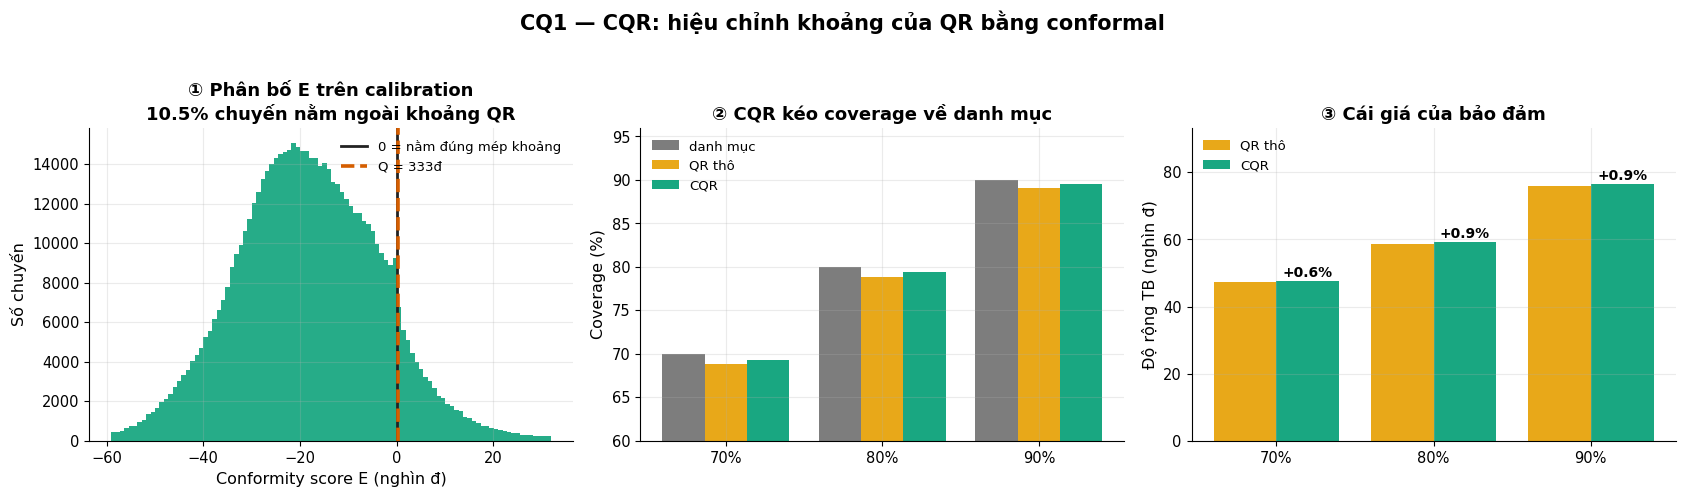

In [3]:
# ═════════ HINH CQ1 — co che va ket qua ═════════
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))

# ① Phan bo conformity score
Q90, E90 = tinh_Q(0.90)
ax[0].hist(E90/1000, bins=100, range=(np.percentile(E90, .5)/1000,
                                      np.percentile(E90, 99.5)/1000),
           color=GREEN, alpha=.85)
ax[0].axvline(0, color=INK, lw=2, label="0 = nằm đúng mép khoảng")
ax[0].axvline(Q90/1000, color=RED, lw=2.6, ls="--", label=f"Q = {Q90:,.0f}đ")
ax[0].set_xlabel("Conformity score E (nghìn đ)"); ax[0].set_ylabel("Số chuyến")
ax[0].legend(frameon=False, fontsize=9.5)
ax[0].set_title(f"① Phân bố E trên calibration\n{(E90>0).mean():.1%} chuyến nằm ngoài "
                "khoảng QR", fontweight="bold")

# ② Coverage QR vs CQR
x = np.arange(len(MUCS)); w = .27
cov_qr = [((qt.gia_that.values >= qt[MUC_PV[m][0]].values) &
           (qt.gia_that.values <= qt[MUC_PV[m][1]].values)).mean() for m in MUCS]
cov_cq = [((qt.gia_that.values >= khoang_cqr(qt, m)[0]) &
           (qt.gia_that.values <= khoang_cqr(qt, m)[1])).mean() for m in MUCS]
ax[1].bar(x - w, [m*100 for m in MUCS], w, color=MUT, alpha=.85, label="danh mục")
ax[1].bar(x, [c_*100 for c_ in cov_qr], w, color=ORANGE, alpha=.9, label="QR thô")
ax[1].bar(x + w, [c_*100 for c_ in cov_cq], w, color=GREEN, alpha=.9, label="CQR")
ax[1].set_xticks(x); ax[1].set_xticklabels([f"{m:.0%}" for m in MUCS])
ax[1].set_ylabel("Coverage (%)"); ax[1].set_ylim(60, 96)
ax[1].legend(frameon=False, fontsize=9.5)
ax[1].set_title("② CQR kéo coverage về danh mục", fontweight="bold")

# ③ Cai gia phai tra
rong_qr = [(qt[MUC_PV[m][1]].values - qt[MUC_PV[m][0]].values).mean() for m in MUCS]
rong_cq = [(khoang_cqr(qt, m)[1] - khoang_cqr(qt, m)[0]).mean() for m in MUCS]
ax[2].bar(x - .2, [r/1000 for r in rong_qr], .4, color=ORANGE, alpha=.9, label="QR thô")
ax[2].bar(x + .2, [r/1000 for r in rong_cq], .4, color=GREEN, alpha=.9, label="CQR")
for i, (a_, b_) in enumerate(zip(rong_qr, rong_cq)):
    ax[2].text(i + .2, b_/1000 + 1.2, f"{b_/a_-1:+.1%}", ha="center", fontsize=10,
               fontweight="bold")
ax[2].set_xticks(x); ax[2].set_xticklabels([f"{m:.0%}" for m in MUCS])
ax[2].set_ylabel("Độ rộng TB (nghìn đ)")
ax[2].set_ylim(0, max(rong_cq)/1000*1.22)
ax[2].legend(frameon=False, fontsize=9.5)
ax[2].set_title("③ Cái giá của bảo đảm", fontweight="bold")

fig.suptitle("CQ1 — CQR: hiệu chỉnh khoảng của QR bằng conformal",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "CQ1_co_che.png"); plt.show()

## 2. CQR nới hay thu khoảng?

Điểm dễ hiểu nhầm nhất về CQR. Nếu QR vốn bao thừa thì `Q` âm và CQR **thu hẹp** khoảng — vừa
được bảo đảm vừa hẹp hơn. Ở đây QR đang hụt nên `Q` dương.

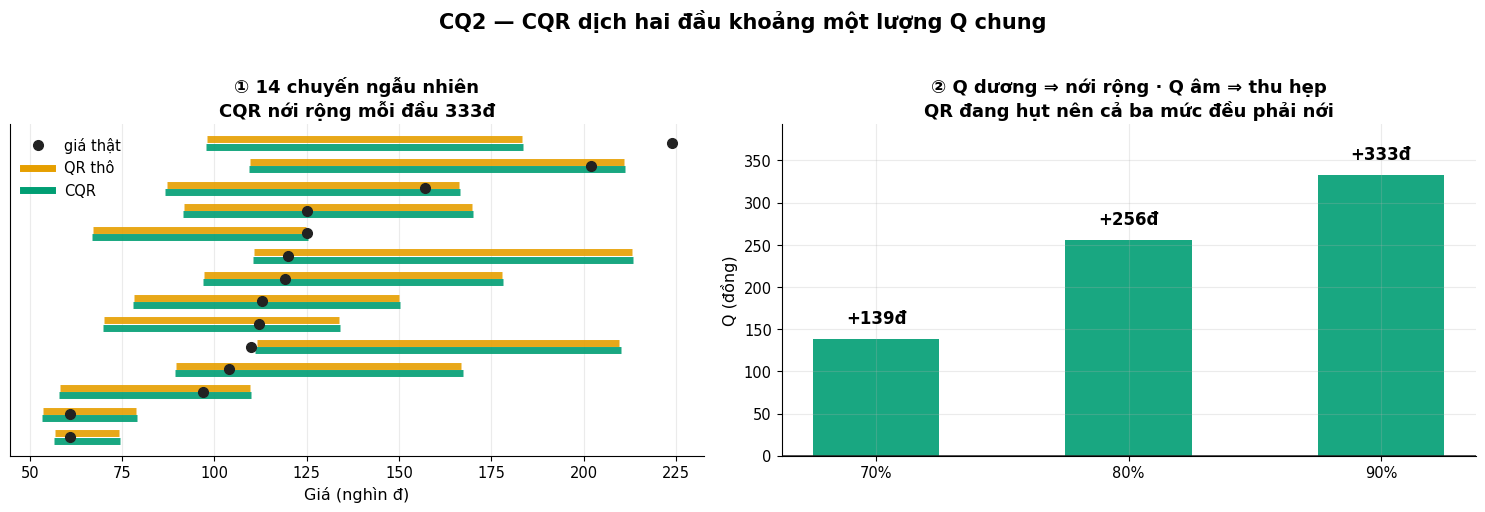

  Muc 70%: Q = +139d -> noi rong moi dau 139d (0.59% do rong)
  Muc 80%: Q = +256d -> noi rong moi dau 256d (0.87% do rong)
  Muc 90%: Q = +333d -> noi rong moi dau 333d (0.88% do rong)

Q rat NHO so voi do rong khoang — nen o panel 1 hai thanh gan nhu trung nhau.
Nghia la QR von da gan dat danh muc, chi can hieu chinh mot chut.
Nhung 'mot chut' do la thu bien QR tu KHONG BAO DAM thanh CO BAO DAM.


In [4]:
# ═════════ HINH CQ2 — noi hay thu ═════════
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Vi du truc quan tren vai chuyen
rng = np.random.default_rng(7)
idx = rng.choice(len(qt), 14, replace=False)
idx = idx[np.argsort(qt.gia_that.values[idx])]
lo_qr = qt["q05"].values[idx]; hi_qr = qt["q95"].values[idx]
lo_cq, hi_cq = khoang_cqr(qt, 0.90)
lo_cq, hi_cq = lo_cq[idx], hi_cq[idx]
y = qt.gia_that.values[idx]
yy = np.arange(len(idx))

for i in yy:
    ax[0].plot([lo_qr[i]/1000, hi_qr[i]/1000], [i+.16, i+.16], lw=5, color=ORANGE,
               solid_capstyle="butt", alpha=.9)
    ax[0].plot([lo_cq[i]/1000, hi_cq[i]/1000], [i-.16, i-.16], lw=5, color=GREEN,
               solid_capstyle="butt", alpha=.9)
ax[0].plot(y/1000, yy, "o", color=INK, ms=7, zorder=5, label="giá thật")
ax[0].plot([], [], lw=5, color=ORANGE, label="QR thô")
ax[0].plot([], [], lw=5, color=GREEN, label="CQR")
ax[0].set_yticks([]); ax[0].set_xlabel("Giá (nghìn đ)")
ax[0].legend(frameon=False)
ax[0].set_title(f"① 14 chuyến ngẫu nhiên\nCQR {'nới rộng' if Q90>0 else 'thu hẹp'} "
                f"mỗi đầu {abs(Q90):,.0f}đ", fontweight="bold")

# Q theo tung muc
Qs = [tinh_Q(m)[0] for m in MUCS]
ax[1].bar(np.arange(len(MUCS)), Qs, .5,
          color=[GREEN if q > 0 else BLUE for q in Qs], alpha=.9)
ax[1].axhline(0, color=INK, lw=1.8)
# Offset phai theo THANG CUA Q (vai tram dong), khong phai theo nghin dong
lech = max(abs(min(Qs)), abs(max(Qs))) * .04
for i, q in enumerate(Qs):
    ax[1].text(i, q + (lech if q > 0 else -lech), f"{q:+,.0f}đ", ha="center",
               va="bottom" if q > 0 else "top", fontsize=12, fontweight="bold")
ax[1].set_xticks(np.arange(len(MUCS)))
ax[1].set_xticklabels([f"{m:.0%}" for m in MUCS])
ax[1].set_ylabel("Q (đồng)")
ax[1].set_ylim(0, max(Qs) * 1.18)
ax[1].set_title("② Q dương ⇒ nới rộng · Q âm ⇒ thu hẹp\n"
                "QR đang hụt nên cả ba mức đều phải nới", fontweight="bold")

fig.suptitle("CQ2 — CQR dịch hai đầu khoảng một lượng Q chung",
             fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout(); plt.savefig(HINH / "CQ2_noi_hay_thu.png"); plt.show()

for m, q in zip(MUCS, Qs):
    rong = (qt[MUC_PV[m][1]].values - qt[MUC_PV[m][0]].values).mean()
    print(f"  Muc {m:.0%}: Q = {q:+,.0f}d -> "
          f"{'noi rong' if q > 0 else 'thu hep'} moi dau {abs(q):,.0f}d "
          f"({2*abs(q)/rong:.2%} do rong)")
print()
print("Q rat NHO so voi do rong khoang — nen o panel 1 hai thanh gan nhu trung nhau.")
print("Nghia la QR von da gan dat danh muc, chi can hieu chinh mot chut.")
print("Nhung 'mot chut' do la thu bien QR tu KHONG BAO DAM thanh CO BAO DAM.")

## 3. Phân rã theo band giá

CQR thừa hưởng tính thích ứng của QR. Nhưng `Q` là **một hằng số tính bằng đồng** cộng đều cho
mọi chuyến — với chuyến rẻ thì `Q` chiếm tỷ trọng lớn hơn nhiều so với chuyến đắt. Điều đó có
làm hỏng tính đều không?

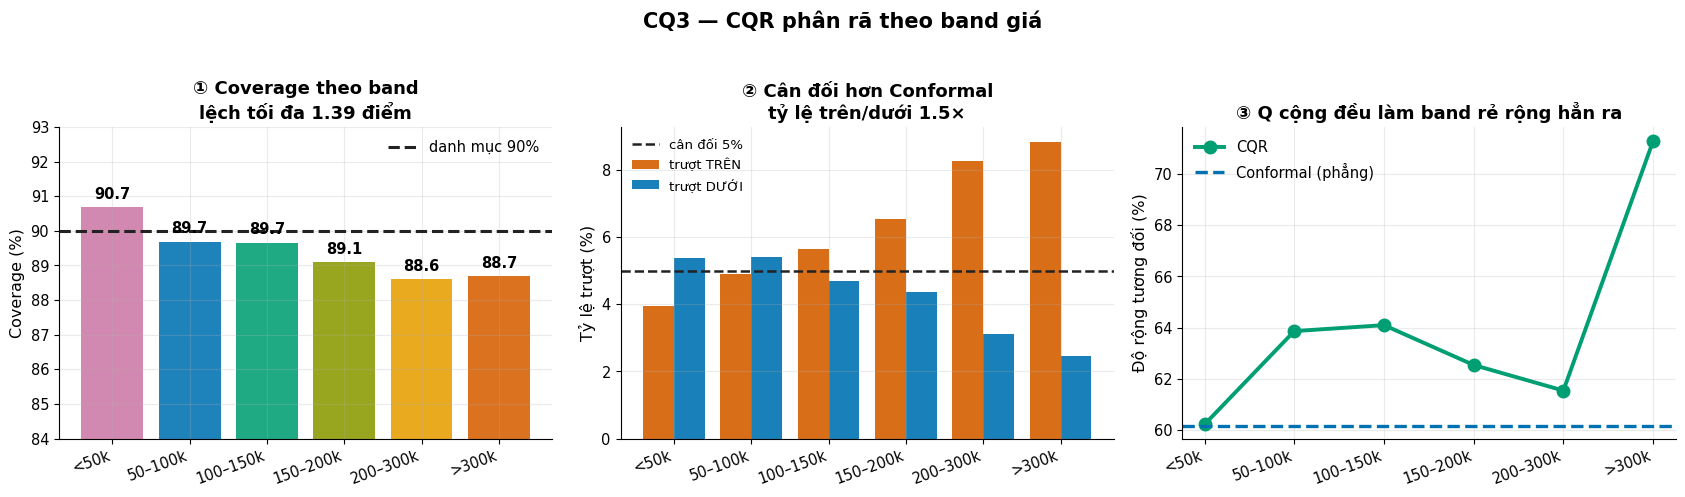

      Band   coverage      rel    tren    duoi
----------------------------------------------
      <50k     90.68%    60.2%   3.94%   5.39%
   50–100k     89.68%    63.9%   4.91%   5.41%
  100–150k     89.66%    64.1%   5.65%   4.69%
  150–200k     89.09%    62.5%   6.53%   4.38%
  200–300k     88.61%    61.5%   8.27%   3.13%
     >300k     88.69%    71.3%   8.84%   2.47%


In [5]:
# ═════════ HINH CQ3 — theo band gia ═════════
def band_cqr(muc):
    lo, hi = khoang_cqr(qt, muc)
    d = pd.DataFrame({"band": qt.band.values, "y": qt.gia_that.values,
                      "p": qt.p_hybrid.values, "lo": lo, "hi": hi})
    d["trong"] = (d.y >= d.lo) & (d.y <= d.hi)
    d["rong"] = d.hi - d.lo
    d["rel"] = d.rong / d.p
    d["tren"] = d.y > d.hi; d["duoi"] = d.y < d.lo
    return d.groupby("band", observed=True).agg(
        n=("y", "size"), cvg=("trong", "mean"), rong=("rong", "median"),
        rel=("rel", "median"), tren=("tren", "mean"),
        duoi=("duoi", "mean")).reindex(TEN)


GC = {m: band_cqr(m) for m in MUCS}
gc90 = GC[0.90]
MAU_BAND = [PURPLE, BLUE, GREEN, "#8A9A00", ORANGE, RED]
x = np.arange(len(TEN))

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
ax[0].bar(x, gc90.cvg*100, color=MAU_BAND, alpha=.88)
ax[0].axhline(90, color=INK, lw=2.2, ls="--", label="danh mục 90%")
for i, v in enumerate(gc90.cvg*100):
    ax[0].text(i, v + .25, f"{v:.1f}", ha="center", fontsize=10.5, fontweight="bold")
ax[0].set_xticks(x); ax[0].set_xticklabels(TEN, rotation=20, ha="right")
ax[0].set_ylabel("Coverage (%)"); ax[0].set_ylim(84, 93)
ax[0].legend(frameon=False)
ax[0].set_title(f"① Coverage theo band\nlệch tối đa {abs(gc90.cvg*100-90).max():.2f} điểm",
                fontweight="bold")

ax[1].bar(x - .2, gc90.tren*100, .4, color=RED, alpha=.9, label="trượt TRÊN")
ax[1].bar(x + .2, gc90.duoi*100, .4, color=BLUE, alpha=.9, label="trượt DƯỚI")
ax[1].axhline(5, color=INK, lw=1.8, ls="--", label="cân đối 5%")
ax[1].set_xticks(x); ax[1].set_xticklabels(TEN, rotation=20, ha="right")
ax[1].set_ylabel("Tỷ lệ trượt (%)")
ax[1].legend(frameon=False, fontsize=9.5)
ax[1].set_title(f"② Cân đối hơn Conformal\ntỷ lệ trên/dưới "
                f"{gc90.tren.mean()/gc90.duoi.mean():.1f}×", fontweight="bold")

ax[2].plot(x, gc90.rel*100, marker="o", ms=9, lw=2.8, color=GREEN, label="CQR")
ax[2].axhline(2*q90_conf*100, color=BLUE, lw=2.4, ls="--", label="Conformal (phẳng)")
ax[2].set_xticks(x); ax[2].set_xticklabels(TEN, rotation=20, ha="right")
ax[2].set_ylabel("Độ rộng tương đối (%)")
ax[2].legend(frameon=False)
ax[2].set_title("③ Q cộng đều làm band rẻ rộng hẳn ra", fontweight="bold")

fig.suptitle("CQ3 — CQR phân rã theo band giá", fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "CQ3_theo_band.png"); plt.show()

print(f"{'Band':>10s} {'coverage':>10s} {'rel':>8s} {'tren':>7s} {'duoi':>7s}")
print("-" * 46)
for b in TEN:
    r = gc90.loc[b]
    print(f"{b:>10s} {r.cvg:>10.2%} {r.rel:>8.1%} {r.tren:>7.2%} {r.duoi:>7.2%}")

## 4. Coverage điều kiện trên ba chiều còn lại

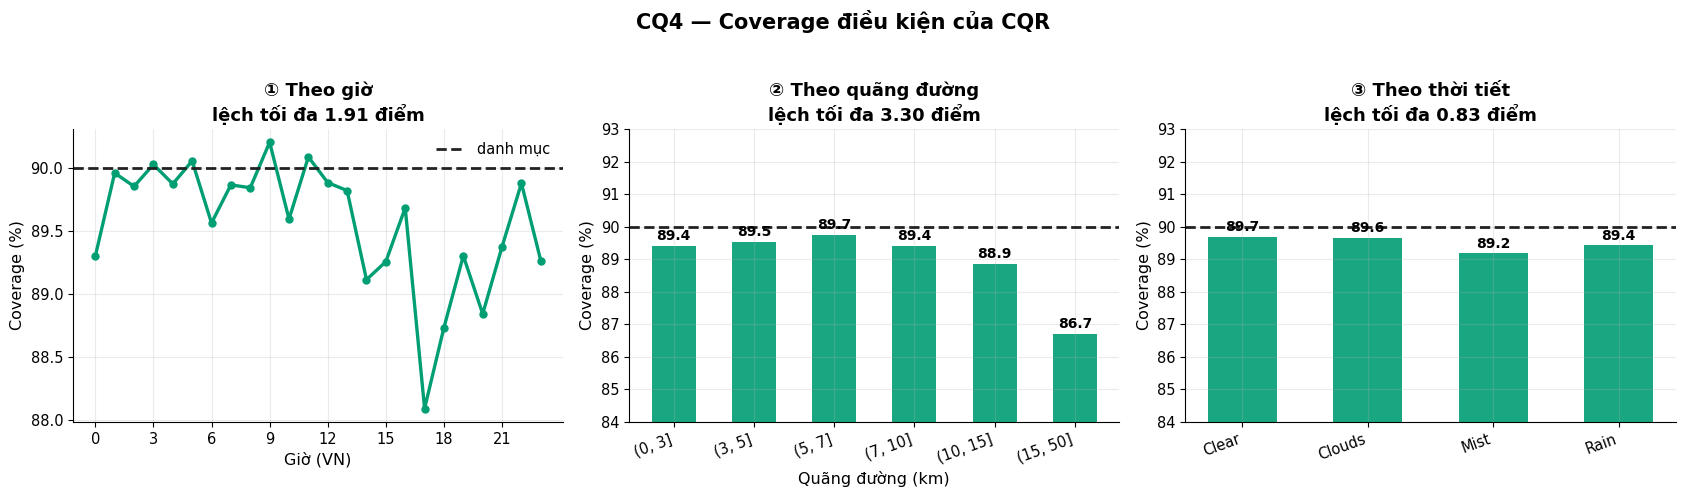

Lech coverage toi da (diem %):
  theo band giá   : 1.39
  theo giờ        : 1.91
  theo quãng đường: 3.30
  theo thời tiết  : 0.83


In [6]:
# ═════════ HINH CQ4 — gio, quang duong, thoi tiet ═════════
lo, hi = khoang_cqr(qt, 0.90)
d = qt.assign(lo=lo, hi=hi)
d["trong"] = (d.gia_that >= d.lo) & (d.gia_that <= d.hi)
d["km"] = pd.cut(d.quote_distance, [0, 3, 5, 7, 10, 15, 50])

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
gh = d.groupby("gio_vn", observed=True).trong.mean()
ax[0].plot(gh.index, gh*100, marker="o", ms=5, lw=2.4, color=GREEN)
ax[0].axhline(90, color=INK, lw=2, ls="--", label="danh mục")
ax[0].set_xlabel("Giờ (VN)"); ax[0].set_ylabel("Coverage (%)")
ax[0].set_xticks(range(0, 24, 3)); ax[0].legend(frameon=False)
ax[0].set_title(f"① Theo giờ\nlệch tối đa {abs(gh*100-90).max():.2f} điểm",
                fontweight="bold")

gk = d.groupby("km", observed=True).trong.mean()
xx = np.arange(len(gk))
ax[1].bar(xx, gk*100, .55, color=GREEN, alpha=.9)
ax[1].axhline(90, color=INK, lw=2, ls="--")
for i, v in enumerate(gk*100):
    ax[1].text(i, v + .18, f"{v:.1f}", ha="center", fontsize=10, fontweight="bold")
ax[1].set_xticks(xx); ax[1].set_xticklabels([str(i) for i in gk.index],
                                            rotation=20, ha="right")
ax[1].set_xlabel("Quãng đường (km)"); ax[1].set_ylabel("Coverage (%)")
ax[1].set_ylim(84, 93)
ax[1].set_title(f"② Theo quãng đường\nlệch tối đa {abs(gk*100-90).max():.2f} điểm",
                fontweight="bold")

gw = d.groupby("weather_main", observed=True).trong.mean()
xw = np.arange(len(gw))
ax[2].bar(xw, gw*100, .55, color=GREEN, alpha=.9)
ax[2].axhline(90, color=INK, lw=2, ls="--")
for i, v in enumerate(gw*100):
    ax[2].text(i, v + .18, f"{v:.1f}", ha="center", fontsize=10, fontweight="bold")
ax[2].set_xticks(xw); ax[2].set_xticklabels(gw.index, rotation=20, ha="right")
ax[2].set_ylabel("Coverage (%)"); ax[2].set_ylim(84, 93)
ax[2].set_title(f"③ Theo thời tiết\nlệch tối đa {abs(gw*100-90).max():.2f} điểm",
                fontweight="bold")

fig.suptitle("CQ4 — Coverage điều kiện của CQR", fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "CQ4_coverage_dieu_kien.png"); plt.show()

print("Lech coverage toi da (diem %):")
print(f"  theo band giá   : {abs(gc90.cvg*100-90).max():.2f}")
print(f"  theo giờ        : {abs(gh*100-90).max():.2f}")
print(f"  theo quãng đường: {abs(gk*100-90).max():.2f}")
print(f"  theo thời tiết  : {abs(gw*100-90).max():.2f}")

---

# Kết luận về phương pháp 3

| | |
|---|---|
| **Điểm mạnh** | Vừa **thích ứng** vừa có **bảo đảm hữu hạn mẫu** · coverage điều kiện **đều nhất** trong ba phương pháp · trượt trên/dưới cân đối hơn Conformal |
| **Điểm yếu** | Khoảng **rộng nhất** · cần train và lưu 21 model quantile · `Q` cộng đều bằng đồng nên band giá rẻ bị nới quá tay |
| **Khi nào dùng** | Khi cần bảo đảm **và** coverage đều giữa các nhóm, chấp nhận khoảng rộng hơn ~5% |

Xem `04_SO_SANH` để đặt cạnh hai phương pháp kia và chốt lựa chọn.